## Preamble

In [207]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from cpymad.madx import Madx

# Comment out the following lines if plotting cells give an error
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
from plot_settings import setPlotSettings
setPlotSettings(font=True)

## Case 1 -- sextupoles off

In [208]:
ring_file = '''
!==================================================================
! Simple FODO ring with periodic optics, surveying & chromaticities
! Authors: Todd Satogata, Steve Peggs 
! Last edited: September 2.2025
!==================================================================

beam, particle = proton, energy = 275.0;
assign, echo = madx.log;

title,'Simple FODO ring';

! Geometry
Ncells  = 17;                ! Number of FODO cells in the ring
Theta   = pi / Ncells;       ! Arc dipole bend angle 
Ldrift  = 0.5;                ! Drift length
Ldipole = 10.0;              ! Arc dipole length
Lquad   = 1.0;               ! Total quad length
Lsext   = 0.5;               ! Sextupole length

! Strengths
KF    =  0.09020;            ! m^(-2)
KD    = -0.09320;            ! m^(-2)
KSF   =  0.0;                ! m^(-3)
KSD   = -0.0;                ! m^(-3)
!KSF   =  0.018020;          ! m^(-3)
!KSD   = -0.030628;          ! m^(-3)

! Magnets
MQ:  marker;                                  ! At the center of every quad
DRI: DRIFT,         L = Ldrift;
DIP: SBEND,         L = Ldipole, ANGLE = Theta;  ! Main arc dipole
QFhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KF;       ! HALF quads
QDhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KD;
SF:  SEXTUPOLE,     L = Lsext, K2 = KSF;
SD:  SEXTUPOLE,     L = Lsext, K2 = KSD;

! Beamlines
fodo_fd:   line = (QFhalf, SF, DIP, DRI, QDhalf);
fodo_df:   line = (QDhalf, SD, DIP, DRI, QFhalf);
fodo_cell: line = (MQ, fodo_fd, MQ, fodo_df);
! ring:      line = (Ncells*fodo_cell);   ! This FAILS !
ring:      line = (17*fodo_cell, MQ);

!=========================================================================
! Text and value output go to madx.log, the previously named echo filenane

print, text ='' ;
print,  text = 'Text output going to ASSIGNed echo file';
printf, text = 'Theta =  %8.6f radians', value = Theta;
print, text ='';


!=========================================================================
! Twiss output, text and plot

! Define the columns & formats
select, FLAG = TWISS, CLASS = MQ, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
set, format="-15s", "11.6f";

use, sequence = ring;
twiss, save, file = ring.twi;
plot, haxis=s, vaxis1 =betx,bety, vaxis2=dx, vmin=0,0, vmax=60,2, colour=100, file = ring;

!=========================================================================
! Survey output

! Define the columns & formats
select, FLAG = SURVEY, CLASS = MQ, column = name, s, x,y,z, theta;
! select, FLAG = SURVEY, CLASS = MQ;   ! Verbose output
set, format="-15s", "11.6f";

use, SEQUENCE = ring;
Survey, FILE = ring.surv;


!=========================================================================
! Tune & chromaticity output

print,  text ='' ;
printf, text = 'H & V tunes          (Q1,Q2)    = %8.6f %8.6f', value = TABLE(SUMM,Q1),  TABLE(SUMM,Q2);
printf, text = 'H & V chromaticities (DQ1, DQ2) = %8.6f %8.6f', value = TABLE(SUMM,DQ1),  TABLE(SUMM,DQ2);
print,  text = '! Find DQ1 & DQ2 from ++++++ table: summ printout in madx.log !';
print,  text ='' ;

!----------------------------------------------------------
stop;


COMMENTS: ................................................
0) Chromaticities DQ1 & DQ2 are inaccessible by "printf" into madx.log !
'''

In [209]:
madx = Madx(stdout=False)
madx.input(ring_file)
twiss = madx.table.twiss

### Phase advance

In [210]:
q1, q2 = madx.table.summ.q1[0], madx.table.summ.q2[0]

For one cell,
$$ \mu_{x,y} = 2\pi Q_{x,y} $$
so we will have to divide by the number of cells to find the phase advance per cell.

In [211]:
ncells = 17
muH = q1*2*pi/ncells
print('Horizontal phase advance:')
print(muH)
muV = q2*2*pi/ncells
print('Vertical phase advance:')
print(muV)

Horizontal phase advance:
1.1692698618979371
Vertical phase advance:
1.1672321834692327


In [212]:
quad = 0.5
sext = 0.5
dip = 10
dri = 0.5
cell = quad + sext + dip + dri + 2*quad + sext + dip + dri + quad
print('Length of half-cell:')
print(f'{cell/2} m')

Length of half-cell:
12.0 m


In [213]:
print('beta/L from MAD-X:')
betamax_L = np.max(twiss.betx)/(cell/2)
print(betamax_L)

beta/L from MAD-X:
3.2519099628687993


Equation 3.50:
$$ \frac{\beta_{max}}{L} = \frac{1+\sin{(\Delta\phi/2)}}{{\sin{(\Delta{\phi}/2)}\cos{(\Delta{\phi}/2)} }} $$

In [214]:
s = np.sin(muH/2)
c = np.cos(muH/2)
betamax_L_ana = (1+s)/(s*c)
print('beta/L from analytic expression:')
print(betamax_L_ana)

beta/L from analytic expression:
3.371978642885172


In [215]:
np.abs(betamax_L_ana - betamax_L)/(betamax_L_ana)

np.float64(0.0356077818789618)

### Observations

- Using the phase advance output by MAD-X yields the same result as Equation 3.50 within ~3\% error.

- Equation 3.50 was derived by solving at the center of the quadrupole, where we expect the maximum of the beta function to be. If that maximum is slightly displaced, this could lead to a discrepancy.

### Chromaticities

In [216]:
print('DQ1:')
dq1 = madx.table.summ.dq1[0]
print(dq1)
print('DQ2:')
dq2 = madx.table.summ.dq2[0]
print(dq2)

DQ1:
-2.638521749228602
DQ2:
-2.886338643721945


Equation 9.6:

$$ \chi_{x,NAT} = \chi_{y,NAT} = -Q \frac{\tan{\phi/2}}{{\phi/2}} $$

In [217]:
q1 = madx.table.summ.q1[0]
q2 = madx.table.summ.q2[0]
muH = q1*2*pi/ncells
muV = q2*2*pi/ncells
dq1_ana = -q1*np.tan(muH/2)/(muH/2)
dq2_ana = -q2*np.tan(muH/2)/(muH/2)
print('DQ1 from analytic expression:')
print(dq1_ana)
print('DQ2 from analytic expression:')
print(dq2_ana)

DQ1 from analytic expression:
-3.5812482505404026
DQ2 from analytic expression:
-3.5750072342055446


In [218]:
print('Disagreement:')
print(np.abs((dq1 - dq1_ana)/dq1_ana))
print(np.abs((dq2 - dq2_ana)/dq2_ana))

Disagreement:
0.2632396403040602
0.19263418095897614


### Observations

- The discrepancy between the MAD-X and analytic results for the natural chromaticities is rather large! I suspect this is because 

In [291]:
############## write an interpretation of this result ##############

## Case 3 -- adjust sextupole strength

In [220]:
ring_file_sext = '''
!==================================================================
! Simple FODO ring with periodic optics, surveying & chromaticities
! Authors: Todd Satogata, Steve Peggs 
! Last edited: September 2.2025
!==================================================================

beam, particle = proton, energy = 275.0;
assign, echo = madx.log;

title,'Simple FODO ring';

! Geometry
Ncells  = 17;                ! Number of FODO cells in the ring
Theta   = pi / Ncells;       ! Arc dipole bend angle 
Ldrift  = 0.5;                ! Drift length
Ldipole = 10.0;              ! Arc dipole length
Lquad   = 1.0;               ! Total quad length
Lsext   = 0.5;               ! Sextupole length

! Strengths
KF    =  0.09020;            ! m^(-2)
KD    = -0.09320;            ! m^(-2)
!KSF   =  0.0;                ! m^(-3)
!KSD   = -0.0;                ! m^(-3)
KSF   =  0.018020;          ! m^(-3)
KSD   = -0.030628;          ! m^(-3)

! Magnets
MQ:  marker;                                  ! At the center of every quad
DRI: DRIFT,         L = Ldrift;
DIP: SBEND,         L = Ldipole, ANGLE = Theta;  ! Main arc dipole
QFhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KF;       ! HALF quads
QDhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KD;
SF:  SEXTUPOLE,     L = Lsext, K2 = KSF;
SD:  SEXTUPOLE,     L = Lsext, K2 = KSD;

! Beamlines
fodo_fd:   line = (QFhalf, SF, DIP, DRI, QDhalf);
fodo_df:   line = (QDhalf, SD, DIP, DRI, QFhalf);
fodo_cell: line = (MQ, fodo_fd, MQ, fodo_df);
! ring:      line = (Ncells*fodo_cell);   ! This FAILS !
ring:      line = (17*fodo_cell, MQ);

!=========================================================================
! Text and value output go to madx.log, the previously named echo filenane

print, text ='' ;
print,  text = 'Text output going to ASSIGNed echo file';
printf, text = 'Theta =  %8.6f radians', value = Theta;
print, text ='';


!=========================================================================
! Twiss output, text and plot

! Define the columns & formats
select, FLAG = TWISS, CLASS = MQ, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
set, format="-15s", "11.6f";

use, sequence = ring;
twiss, save, file = ring.twi;
plot, haxis=s, vaxis1 =betx,bety, vaxis2=dx, vmin=0,0, vmax=60,2, colour=100, file = ring;

!=========================================================================
! Survey output

! Define the columns & formats
select, FLAG = SURVEY, CLASS = MQ, column = name, s, x,y,z, theta;
! select, FLAG = SURVEY, CLASS = MQ;   ! Verbose output
set, format="-15s", "11.6f";

use, SEQUENCE = ring;
Survey, FILE = ring.surv;


!=========================================================================
! Tune & chromaticity output

print,  text ='' ;
printf, text = 'H & V tunes          (Q1,Q2)    = %8.6f %8.6f', value = TABLE(SUMM,Q1),  TABLE(SUMM,Q2);
printf, text = 'H & V chromaticities (DQ1, DQ2) = %8.6f %8.6f', value = TABLE(SUMM,DQ1),  TABLE(SUMM,DQ2);
print,  text = '! Find DQ1 & DQ2 from ++++++ table: summ printout in madx.log !';
print,  text ='' ;

!----------------------------------------------------------
stop;


COMMENTS: ................................................
0) Chromaticities DQ1 & DQ2 are inaccessible by "printf" into madx.log !
'''

In [221]:
madx_sext = Madx(stdout=False)
madx_sext.input(ring_file_sext)
twiss_sext = madx_sext.table.twiss

In [222]:
print('DQ1:')
dq1 = madx_sext.table.summ.dq1[0]
print(dq1)
print('DQ2:')
dq2 = madx_sext.table.summ.dq2[0]
print(dq2)

DQ1:
-8.077518232394408e-05
DQ2:
-9.282251097200978e-05


$\therefore$ The values of KSF and KSD that make the chromaticities zero are $\boxed{0.018020}$ and $\boxed{-0.030628}$ respectively.

Equation 9.12:
$$ S = \frac{1}{2} K L_{sext} $$

In [223]:
kf = madx_sext.elements.sf.k2
sf = 0.5*kf*sext
print('SF from analytic:')
print(sf)
kd = madx_sext.elements.sd.k2
sd = 0.5*kd*sext
print('SD from analytic:')
print(sd)

SF from analytic:
0.004505
SD from analytic:
-0.007657


### Observations:

- The analytic expression yielded values very close to zero, as expected.

- We saw before that the chromaticity was nonzero without the sextupole turned on, and here the addition of a very small sextupole term was enough to suppress these chromatic effects. I suspect this is because sextupole fields are nonlinear, so only small sextupole terms are needed to keep the particle motion stable.

## Case 4 -- adjust lengths

Let us start by seeing what happens if the drift length goes to zero and the sextupole length to (nearly) 1 m s.t. the sum is preserved.

In [224]:
ring_file_smalldrift = '''
!==================================================================
! Simple FODO ring with periodic optics, surveying & chromaticities
! Authors: Todd Satogata, Steve Peggs 
! Last edited: September 2.2025
!==================================================================

beam, particle = proton, energy = 275.0;
assign, echo = madx.log;

title,'Simple FODO ring';

! Geometry
Ncells  = 17;                ! Number of FODO cells in the ring
Theta   = pi / Ncells;       ! Arc dipole bend angle 
Ldrift  = 0.001;                ! Drift length
Ldipole = 10.0;              ! Arc dipole length
Lquad   = 1.0;               ! Total quad length
Lsext   = 0.999;               ! Sextupole length

! Strengths
KF    =  0.09020;            ! m^(-2)
KD    = -0.09320;            ! m^(-2)
!KSF   =  0.0;                ! m^(-3)
!KSD   = -0.0;                ! m^(-3)
KSF   =  0.018020;          ! m^(-3)
KSD   = -0.030628;          ! m^(-3)

! Magnets
MQ:  marker;                                  ! At the center of every quad
DRI: DRIFT,         L = Ldrift;
DIP: SBEND,         L = Ldipole, ANGLE = Theta;  ! Main arc dipole
QFhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KF;       ! HALF quads
QDhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KD;
SF:  SEXTUPOLE,     L = Lsext, K2 := KSF;
SD:  SEXTUPOLE,     L = Lsext, K2 := KSD;

! Beamlines
fodo_fd:   line = (QFhalf, SF, DIP, DRI, QDhalf);
fodo_df:   line = (QDhalf, SD, DIP, DRI, QFhalf);
fodo_cell: line = (MQ, fodo_fd, MQ, fodo_df);
! ring:      line = (Ncells*fodo_cell);   ! This FAILS !
ring:      line = (17*fodo_cell, MQ);

!=========================================================================
! Text and value output go to madx.log, the previously named echo filenane

print, text ='' ;
print,  text = 'Text output going to ASSIGNed echo file';
printf, text = 'Theta =  %8.6f radians', value = Theta;
print, text ='';


!=========================================================================
! Twiss output, text and plot

! Define the columns & formats
select, FLAG = TWISS, CLASS = MQ, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
set, format="-15s", "11.6f";

use, sequence = ring;
twiss, save, file = ring.twi;
plot, haxis=s, vaxis1 =betx,bety, vaxis2=dx, vmin=0,0, vmax=60,2, colour=100, file = ring;

!=========================================================================
! Survey output

! Define the columns & formats
select, FLAG = SURVEY, CLASS = MQ, column = name, s, x,y,z, theta;
! select, FLAG = SURVEY, CLASS = MQ;   ! Verbose output
set, format="-15s", "11.6f";

use, SEQUENCE = ring;
Survey, FILE = ring.surv;

MATCH,SEQUENCE=ring;
VARY,NAME=KSF, STEP=0.001;
VARY,NAME=KSD, STEP=0.001;
GLOBAL,SEQUENCE=ring,DQ1=0.0;
GLOBAL,SEQUENCE=ring,DQ2=0.0;
LMDIF,CALLS=5000, TOLERANCE=1.0E-21;
ENDMATCH;


!=========================================================================
! Tune & chromaticity output

print,  text ='' ;
printf, text = 'H & V tunes          (Q1,Q2)    = %8.6f %8.6f', value = TABLE(SUMM,Q1),  TABLE(SUMM,Q2);
printf, text = 'H & V chromaticities (DQ1, DQ2) = %8.6f %8.6f', value = TABLE(SUMM,DQ1),  TABLE(SUMM,DQ2);
print,  text = '! Find DQ1 & DQ2 from ++++++ table: summ printout in madx.log !';
print,  text ='' ;

!----------------------------------------------------------
stop;


COMMENTS: ................................................
0) Chromaticities DQ1 & DQ2 are inaccessible by "printf" into madx.log !
'''

In [225]:
madx_smalldrift = Madx(stdout=False)
madx_smalldrift.input(ring_file_smalldrift)
twiss_smalldrift = madx_smalldrift.table.twiss

In [226]:
print('DQ1:')
dq1 = madx_smalldrift.table.summ.dq1[0]
print(dq1)
print('DQ2:')
dq2 = madx_smalldrift.table.summ.dq2[0]
print(dq2)

DQ1:
-2.8410802969758233e-12
DQ2:
3.1171263583809095e-12


In [227]:
print('KSF:')
print(madx_smalldrift.elements.sf.k2)
print('KSD:')
print(madx_smalldrift.elements.sd.k2)

KSF:
0.009577913988480673
KSD:
-0.015888345997430792


Now let us try the opposite case, where the drift length goes to 1 m and the sextupole length is (nearly) zero.

In [228]:
ring_file_smallsext = '''
!==================================================================
! Simple FODO ring with periodic optics, surveying & chromaticities
! Authors: Todd Satogata, Steve Peggs 
! Last edited: September 2.2025
!==================================================================

beam, particle = proton, energy = 275.0;
assign, echo = madx.log;

title,'Simple FODO ring';

! Geometry
Ncells  = 17;                ! Number of FODO cells in the ring
Theta   = pi / Ncells;       ! Arc dipole bend angle 
Ldrift  = 0.999;                ! Drift length
Ldipole = 10.0;              ! Arc dipole length
Lquad   = 1.0;               ! Total quad length
Lsext   = 0.001;               ! Sextupole length

! Strengths
KF    =  0.09020;            ! m^(-2)
KD    = -0.09320;            ! m^(-2)
!KSF   =  0.0;                ! m^(-3)
!KSD   = -0.0;                ! m^(-3)
KSF   =  0.018020;          ! m^(-3)
KSD   = -0.030628;          ! m^(-3)

! Magnets
MQ:  marker;                                  ! At the center of every quad
DRI: DRIFT,         L = Ldrift;
DIP: SBEND,         L = Ldipole, ANGLE = Theta;  ! Main arc dipole
QFhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KF;       ! HALF quads
QDhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KD;
SF:  SEXTUPOLE,     L = Lsext, K2 := KSF;
SD:  SEXTUPOLE,     L = Lsext, K2 := KSD;

! Beamlines
fodo_fd:   line = (QFhalf, SF, DIP, DRI, QDhalf);
fodo_df:   line = (QDhalf, SD, DIP, DRI, QFhalf);
fodo_cell: line = (MQ, fodo_fd, MQ, fodo_df);
! ring:      line = (Ncells*fodo_cell);   ! This FAILS !
ring:      line = (17*fodo_cell, MQ);

!=========================================================================
! Text and value output go to madx.log, the previously named echo filenane

print, text ='' ;
print,  text = 'Text output going to ASSIGNed echo file';
printf, text = 'Theta =  %8.6f radians', value = Theta;
print, text ='';


!=========================================================================
! Twiss output, text and plot

! Define the columns & formats
select, FLAG = TWISS, CLASS = MQ, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
set, format="-15s", "11.6f";

use, sequence = ring;
twiss, save, file = ring.twi;
plot, haxis=s, vaxis1 =betx,bety, vaxis2=dx, vmin=0,0, vmax=60,2, colour=100, file = ring;

!=========================================================================
! Survey output

! Define the columns & formats
select, FLAG = SURVEY, CLASS = MQ, column = name, s, x,y,z, theta;
! select, FLAG = SURVEY, CLASS = MQ;   ! Verbose output
set, format="-15s", "11.6f";

use, SEQUENCE = ring;
Survey, FILE = ring.surv;


MATCH,SEQUENCE=ring;
VARY,NAME=KSF, STEP=0.001;
VARY,NAME=KSD, STEP=0.001;
GLOBAL,SEQUENCE=ring,DQ1=0.0;
GLOBAL,SEQUENCE=ring,DQ2=0.0;
LMDIF,CALLS=5000, TOLERANCE=1.0E-21;
ENDMATCH;


!=========================================================================
! Tune & chromaticity output

print,  text ='' ;
printf, text = 'H & V tunes          (Q1,Q2)    = %8.6f %8.6f', value = TABLE(SUMM,Q1),  TABLE(SUMM,Q2);
printf, text = 'H & V chromaticities (DQ1, DQ2) = %8.6f %8.6f', value = TABLE(SUMM,DQ1),  TABLE(SUMM,DQ2);
print,  text = '! Find DQ1 & DQ2 from ++++++ table: summ printout in madx.log !';
print,  text ='' ;

!----------------------------------------------------------
stop;


COMMENTS: ................................................
0) Chromaticities DQ1 & DQ2 are inaccessible by "printf" into madx.log !
'''

In [229]:
madx_smallsext = Madx(stdout=False)
madx_smallsext.input(ring_file_smallsext)
twiss_smallsext = madx_smallsext.table.twiss

In [230]:
print('DQ1:')
dq1 = madx_smallsext.table.summ.dq1[0]
print(dq1)
print('DQ2:')
dq2 = madx_smallsext.table.summ.dq2[0]
print(dq2)

DQ1:
-2.7732798323540143e-13
DQ2:
-3.757011008904685e-14


In [231]:
print('KSF:')
print(madx_smallsext.elements.sf.k2)
print('KSD:')
print(madx_smallsext.elements.sd.k2)

KSF:
8.505130755733608
KSD:
-14.812470734405982


## Case 5 -- adjust number of cells

In [235]:
n_vals = np.arange(1,50,5)
C_vals = []
betaxmin_vals = []; betaxmax_vals = []
betaymin_vals = []; betaymax_vals = []
dxmin_vals = []; dxmax_vals = []
ksf_vals = []; ksd_vals = []
for n in n_vals:
    ring_file_iter = f'''
    !==================================================================
    ! Simple FODO ring with periodic optics, surveying & chromaticities
    ! Authors: Todd Satogata, Steve Peggs 
    ! Last edited: September 2.2025
    !==================================================================

    beam, particle = proton, energy = 275.0;
    assign, echo = madx.log;

    title,'Simple FODO ring';

    ! Geometry
    Ncells  = {n};                ! Number of FODO cells in the ring
    Theta   = pi / Ncells;       ! Arc dipole bend angle 
    Ldrift  = 0.5;                ! Drift length
    Ldipole = 10.0;              ! Arc dipole length
    Lquad   = 1.0;               ! Total quad length
    Lsext   = 0.5;               ! Sextupole length

    ! Strengths
    KF    =  0.09020;            ! m^(-2)
    KD    = -0.09320;            ! m^(-2)
    !KSF   =  0.0;                ! m^(-3)
    !KSD   = -0.0;                ! m^(-3)
    KSF   =  0.018020;          ! m^(-3)
    KSD   = -0.030628;          ! m^(-3)

    ! Magnets
    MQ:  marker;                                  ! At the center of every quad
    DRI: DRIFT,         L = Ldrift;
    DIP: SBEND,         L = Ldipole, ANGLE = Theta;  ! Main arc dipole
    QFhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KF;       ! HALF quads
    QDhalf: QUADRUPOLE, L = 0.5*Lquad, K1= KD;
    SF:  SEXTUPOLE,     L = Lsext, K2 = KSF;
    SD:  SEXTUPOLE,     L = Lsext, K2 = KSD;

    ! Beamlines
    fodo_fd:   line = (QFhalf, SF, DIP, DRI, QDhalf);
    fodo_df:   line = (QDhalf, SD, DIP, DRI, QFhalf);
    fodo_cell: line = (MQ, fodo_fd, MQ, fodo_df);
    ! ring:      line = (Ncells*fodo_cell);   ! This FAILS !
    ring:      line = (17*fodo_cell, MQ);

    !=========================================================================
    ! Text and value output go to madx.log, the previously named echo filenane

    print, text ='' ;
    print,  text = 'Text output going to ASSIGNed echo file';
    printf, text = 'Theta =  %8.6f radians', value = Theta;
    print, text ='';


    !=========================================================================
    ! Twiss output, text and plot

    ! Define the columns & formats
    select, FLAG = TWISS, CLASS = MQ, COLUMN = name,s,betx,bety,alfx,alfy,dx,mux,muy;
    set, format="-15s", "11.6f";

    use, sequence = ring;
    twiss, save, file = ring.twi;
    plot, haxis=s, vaxis1 =betx,bety, vaxis2=dx, vmin=0,0, vmax=60,2, colour=100, file = ring;

    !=========================================================================
    ! Survey output

    ! Define the columns & formats
    select, FLAG = SURVEY, CLASS = MQ, column = name, s, x,y,z, theta;
    ! select, FLAG = SURVEY, CLASS = MQ;   ! Verbose output
    set, format="-15s", "11.6f";

    use, SEQUENCE = ring;
    Survey, FILE = ring.surv;

    MATCH,SEQUENCE=ring;
    VARY,NAME=KSF, STEP=0.001;
    VARY,NAME=KSD, STEP=0.001;
    GLOBAL,SEQUENCE=ring,DQ1=0.0;
    GLOBAL,SEQUENCE=ring,DQ2=0.0;
    LMDIF,CALLS=5000, TOLERANCE=1.0E-21;
    ENDMATCH;


    !=========================================================================
    ! Tune & chromaticity output

    print,  text ='' ;
    printf, text = 'H & V tunes          (Q1,Q2)    = %8.6f %8.6f', value = TABLE(SUMM,Q1),  TABLE(SUMM,Q2);
    printf, text = 'H & V chromaticities (DQ1, DQ2) = %8.6f %8.6f', value = TABLE(SUMM,DQ1),  TABLE(SUMM,DQ2);
    print,  text = '! Find DQ1 & DQ2 from ++++++ table: summ printout in madx.log !';
    print,  text ='' ;

    !----------------------------------------------------------
    stop;


    COMMENTS: ................................................
    0) Chromaticities DQ1 & DQ2 are inaccessible by "printf" into madx.log !
    '''
    madx_iter = Madx(stdout=False)
    madx_iter.input(ring_file_iter)
    twiss_iter = madx_iter.table.twiss
    
    # circumference:
    C_vals.append(n*cell)

    # min and max beta:
    betaxmin_vals.append(np.min(twiss_iter.betx))
    betaxmax_vals.append(np.max(twiss_iter.betx))
    betaymin_vals.append(np.min(twiss_iter.bety))
    betaymax_vals.append(np.max(twiss_iter.bety))

    # min and max dx:
    dxmin_vals.append(np.min(twiss_iter.dx))
    dxmax_vals.append(np.max(twiss_iter.dx))

    # ksf and ksd:
    ksf_vals.append(madx_iter.elements.sf.k2)
    ksd_vals.append(madx_iter.elements.sd.k2)

### Circumference of ring

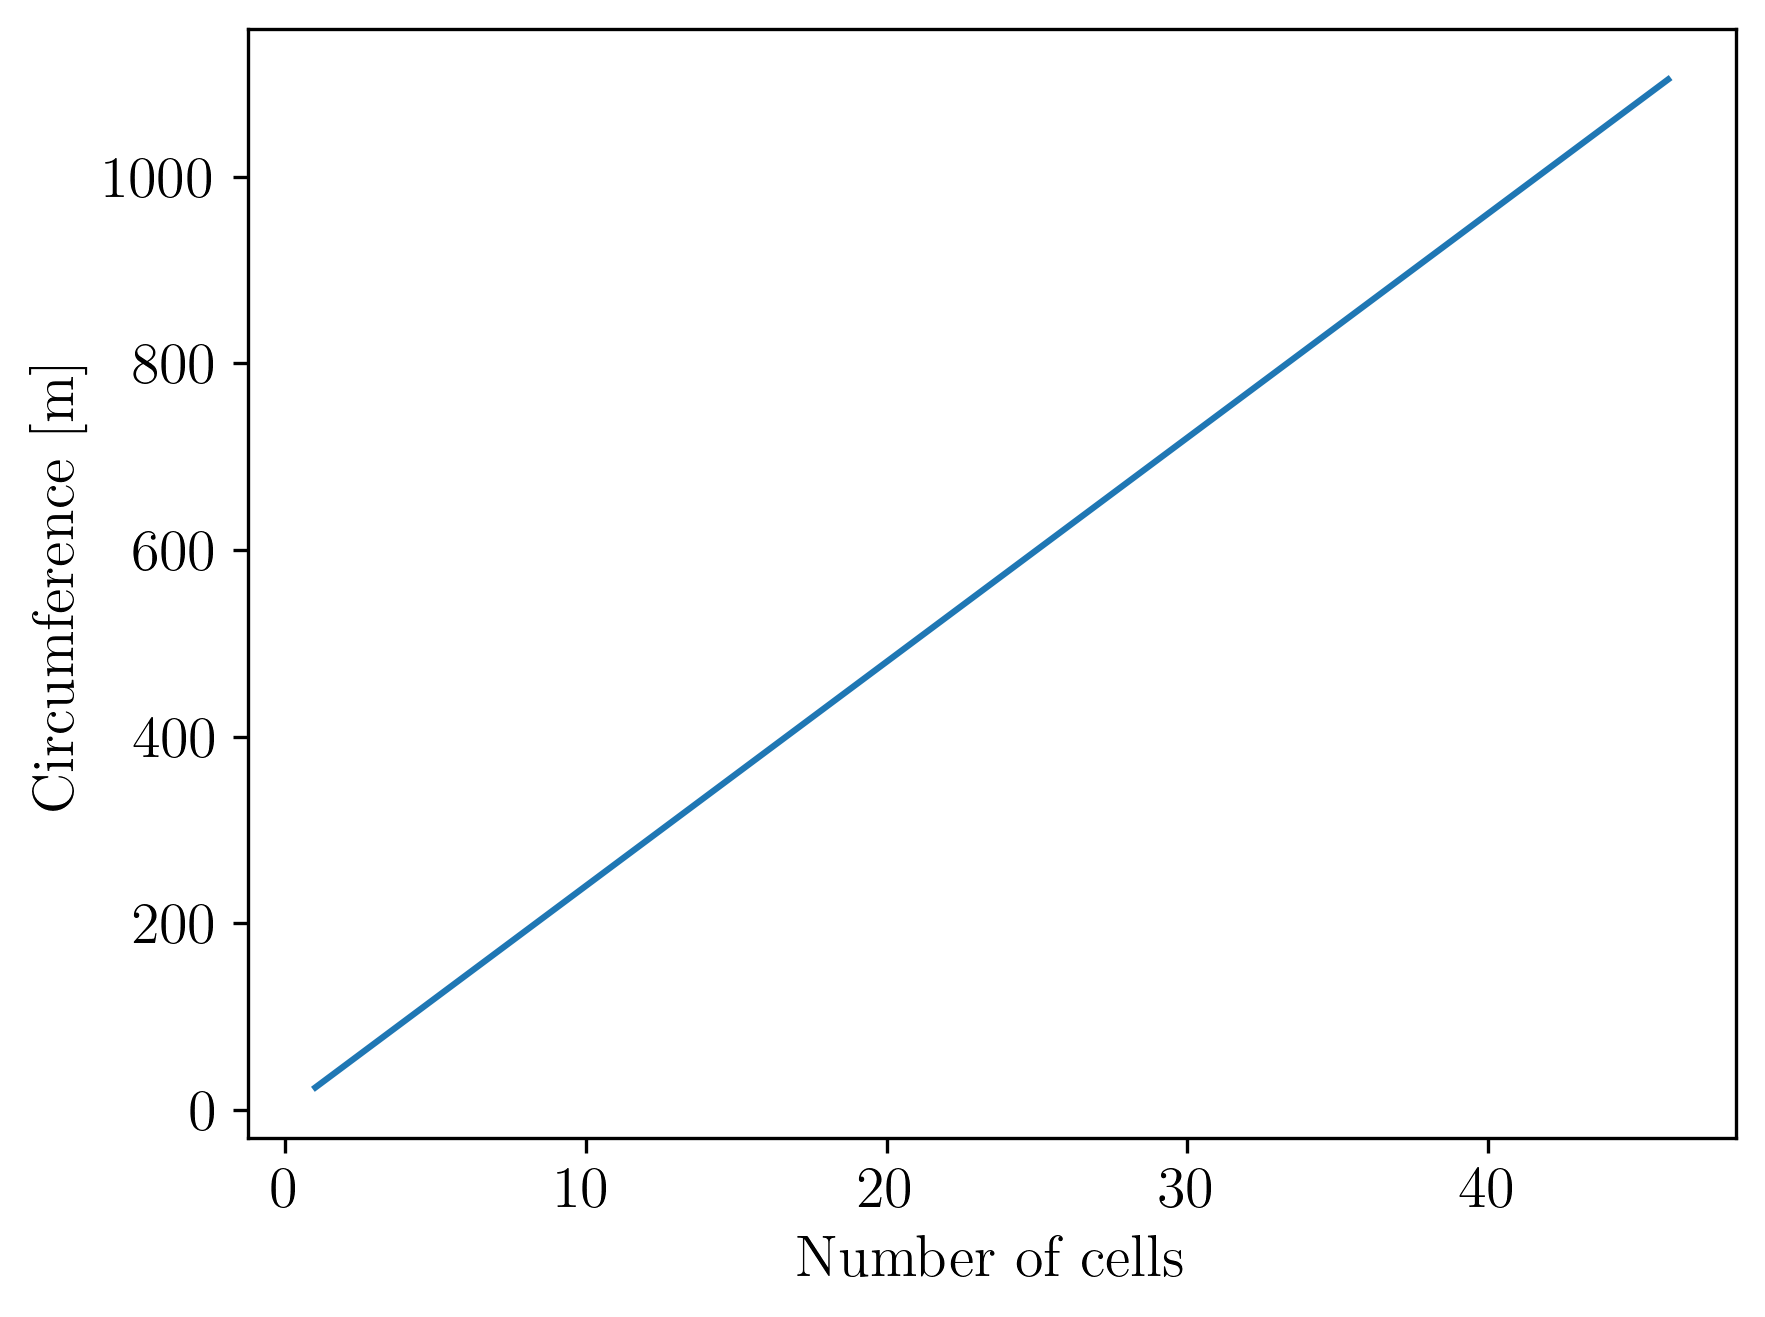

In [281]:
plt.plot(n_vals,C_vals)
plt.ylabel('Circumference [m]')
plt.xlabel('Number of cells')
plt.show()

### Min and max beta

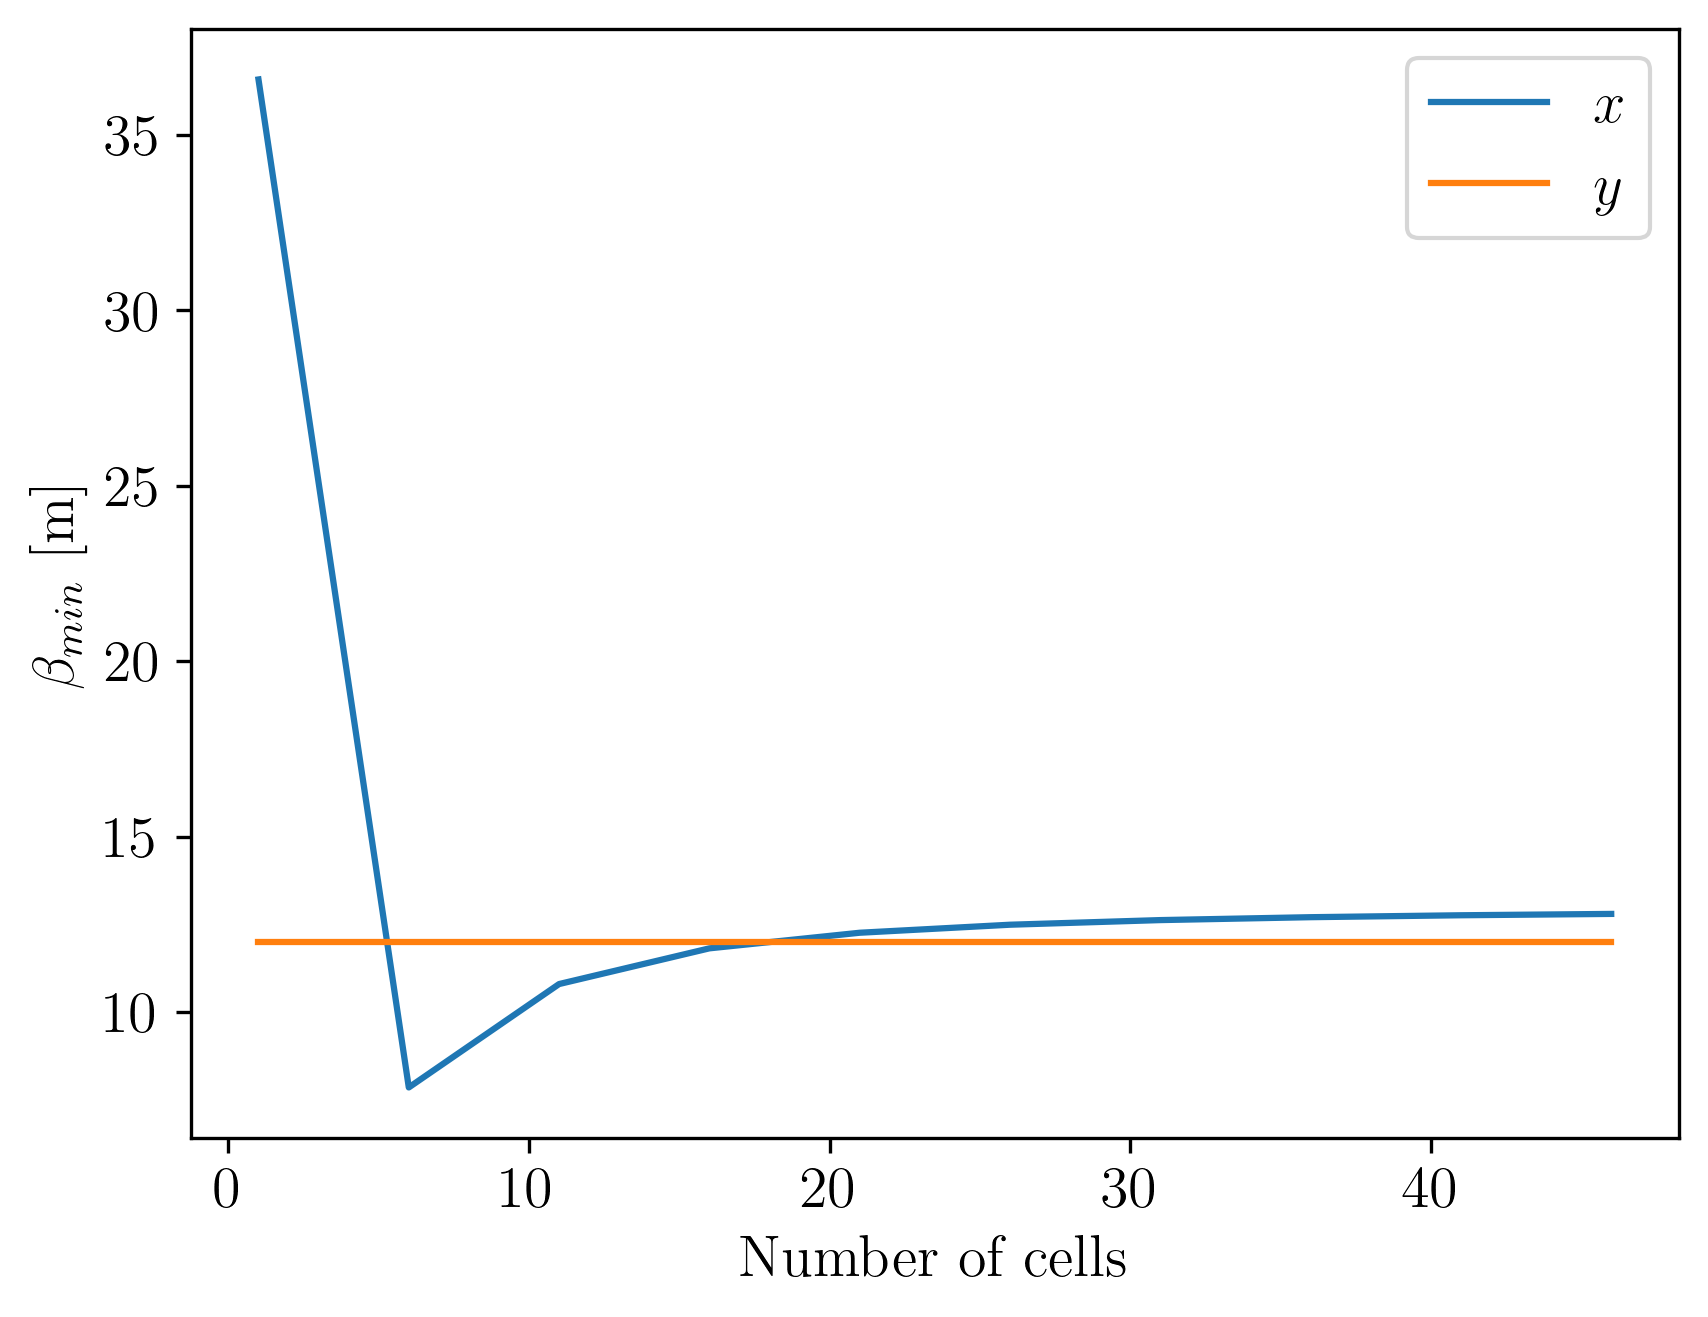

In [282]:
plt.plot(n_vals,betaxmin_vals,label='$x$')
plt.plot(n_vals,betaymin_vals,label='$y$')
plt.ylabel(r'$\beta_{min}$ [m]')
plt.xlabel('Number of cells')
plt.legend()
plt.show()

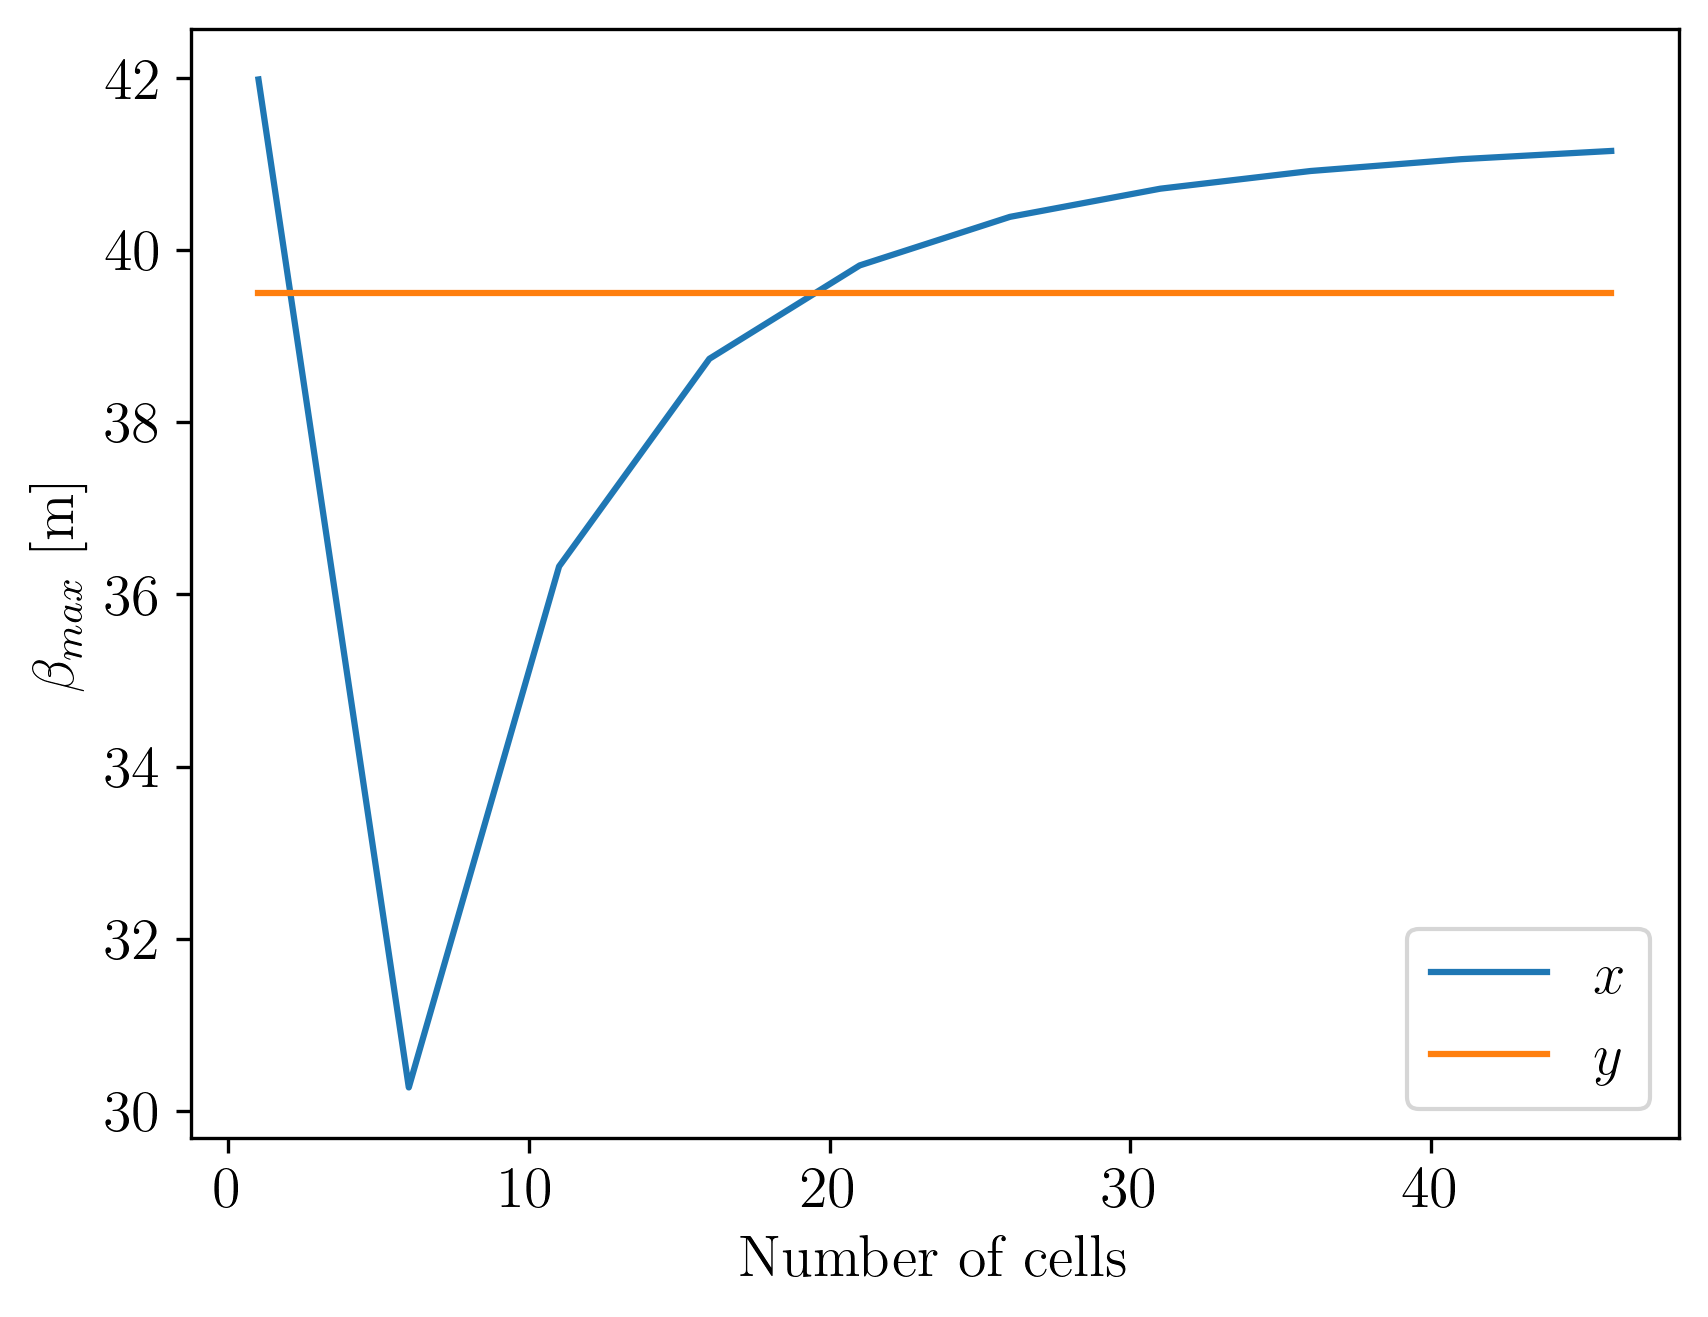

In [283]:
plt.plot(n_vals,betaxmax_vals,label='$x$')
plt.plot(n_vals,betaymax_vals,label='$y$')
plt.ylabel(r'$\beta_{max}$ [m]')
plt.xlabel('Number of cells')
plt.legend()
plt.show()

### Min and max dispersion

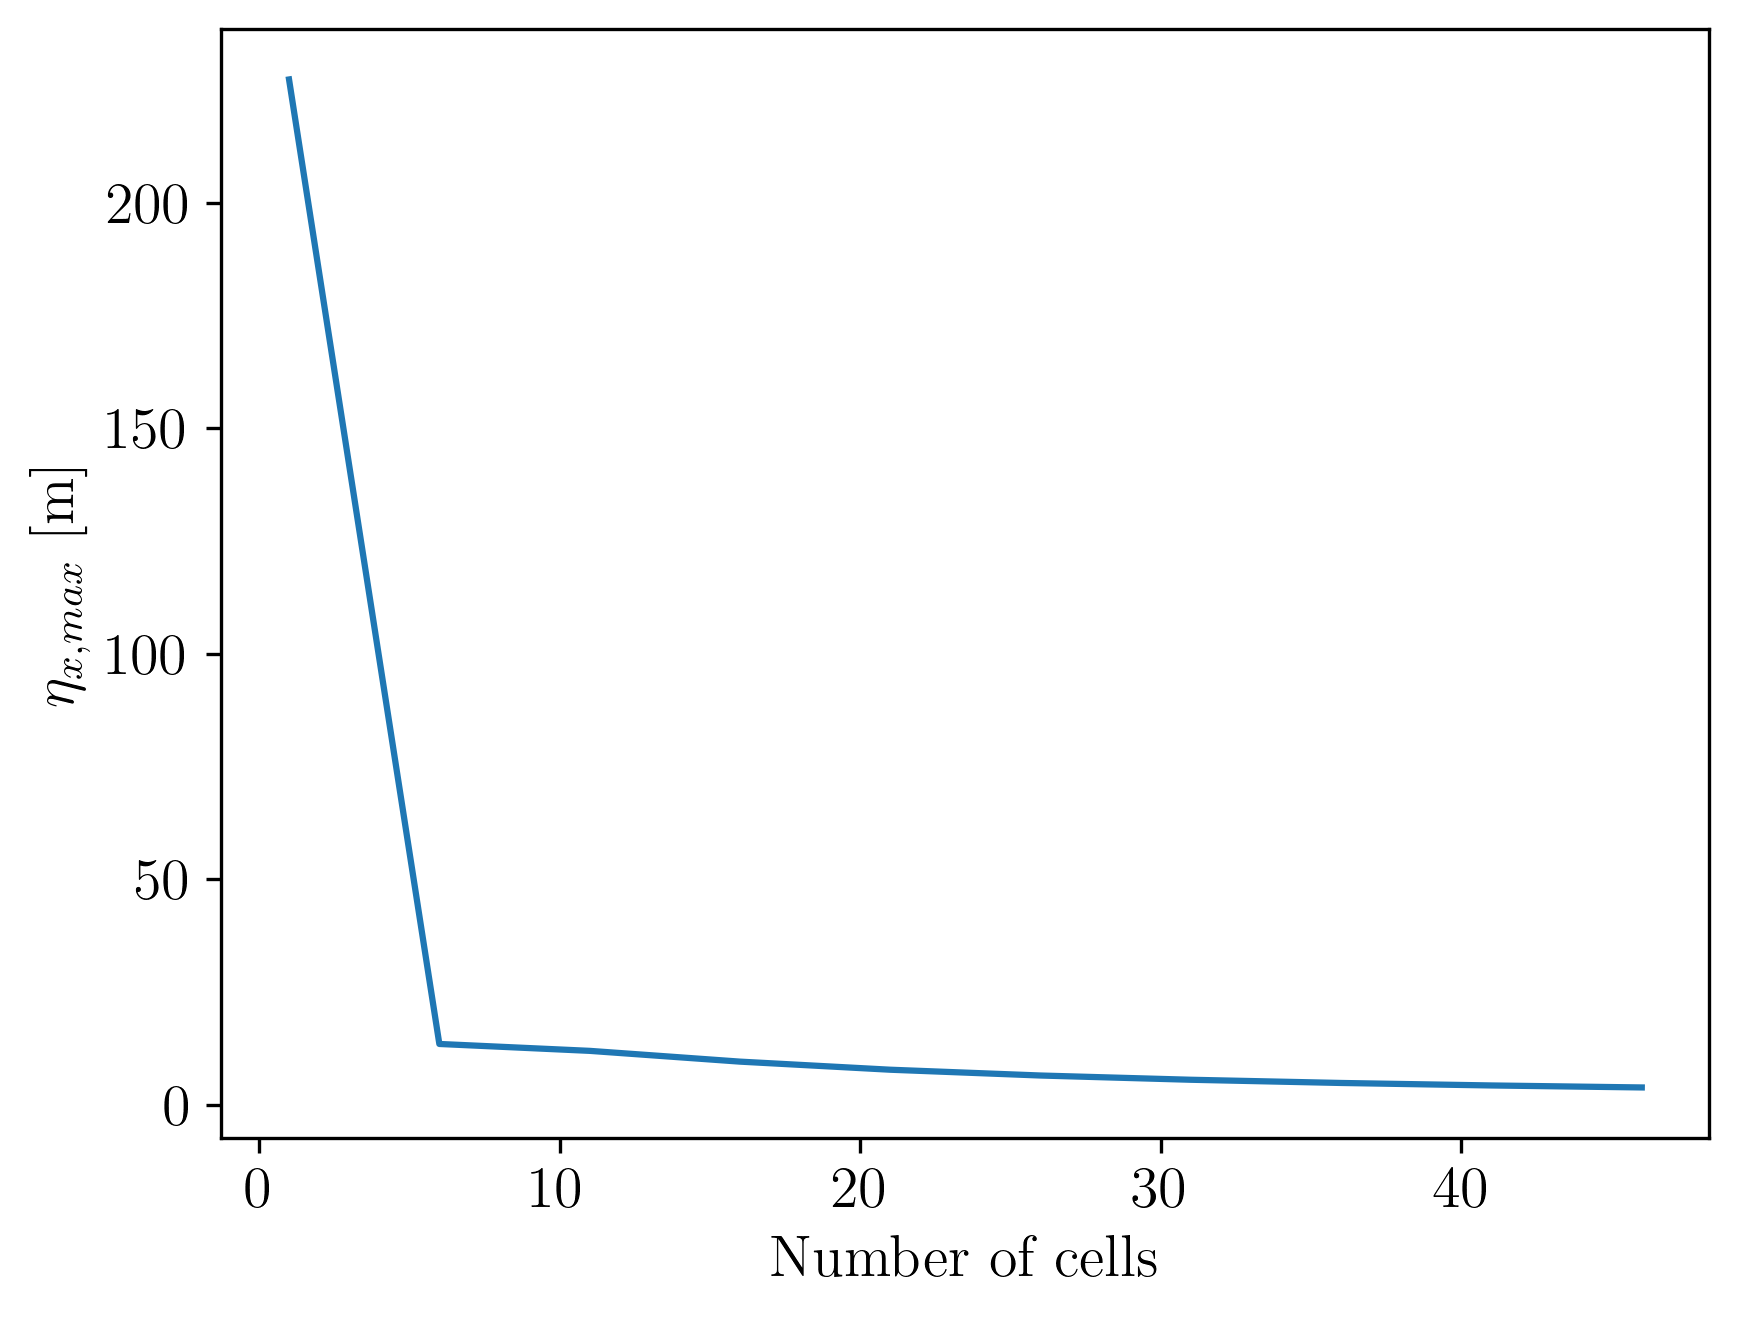

In [284]:
plt.plot(n_vals,dxmax_vals)
plt.ylabel('$\eta_{x,max}$ [m]')
plt.xlabel('Number of cells')
plt.show()

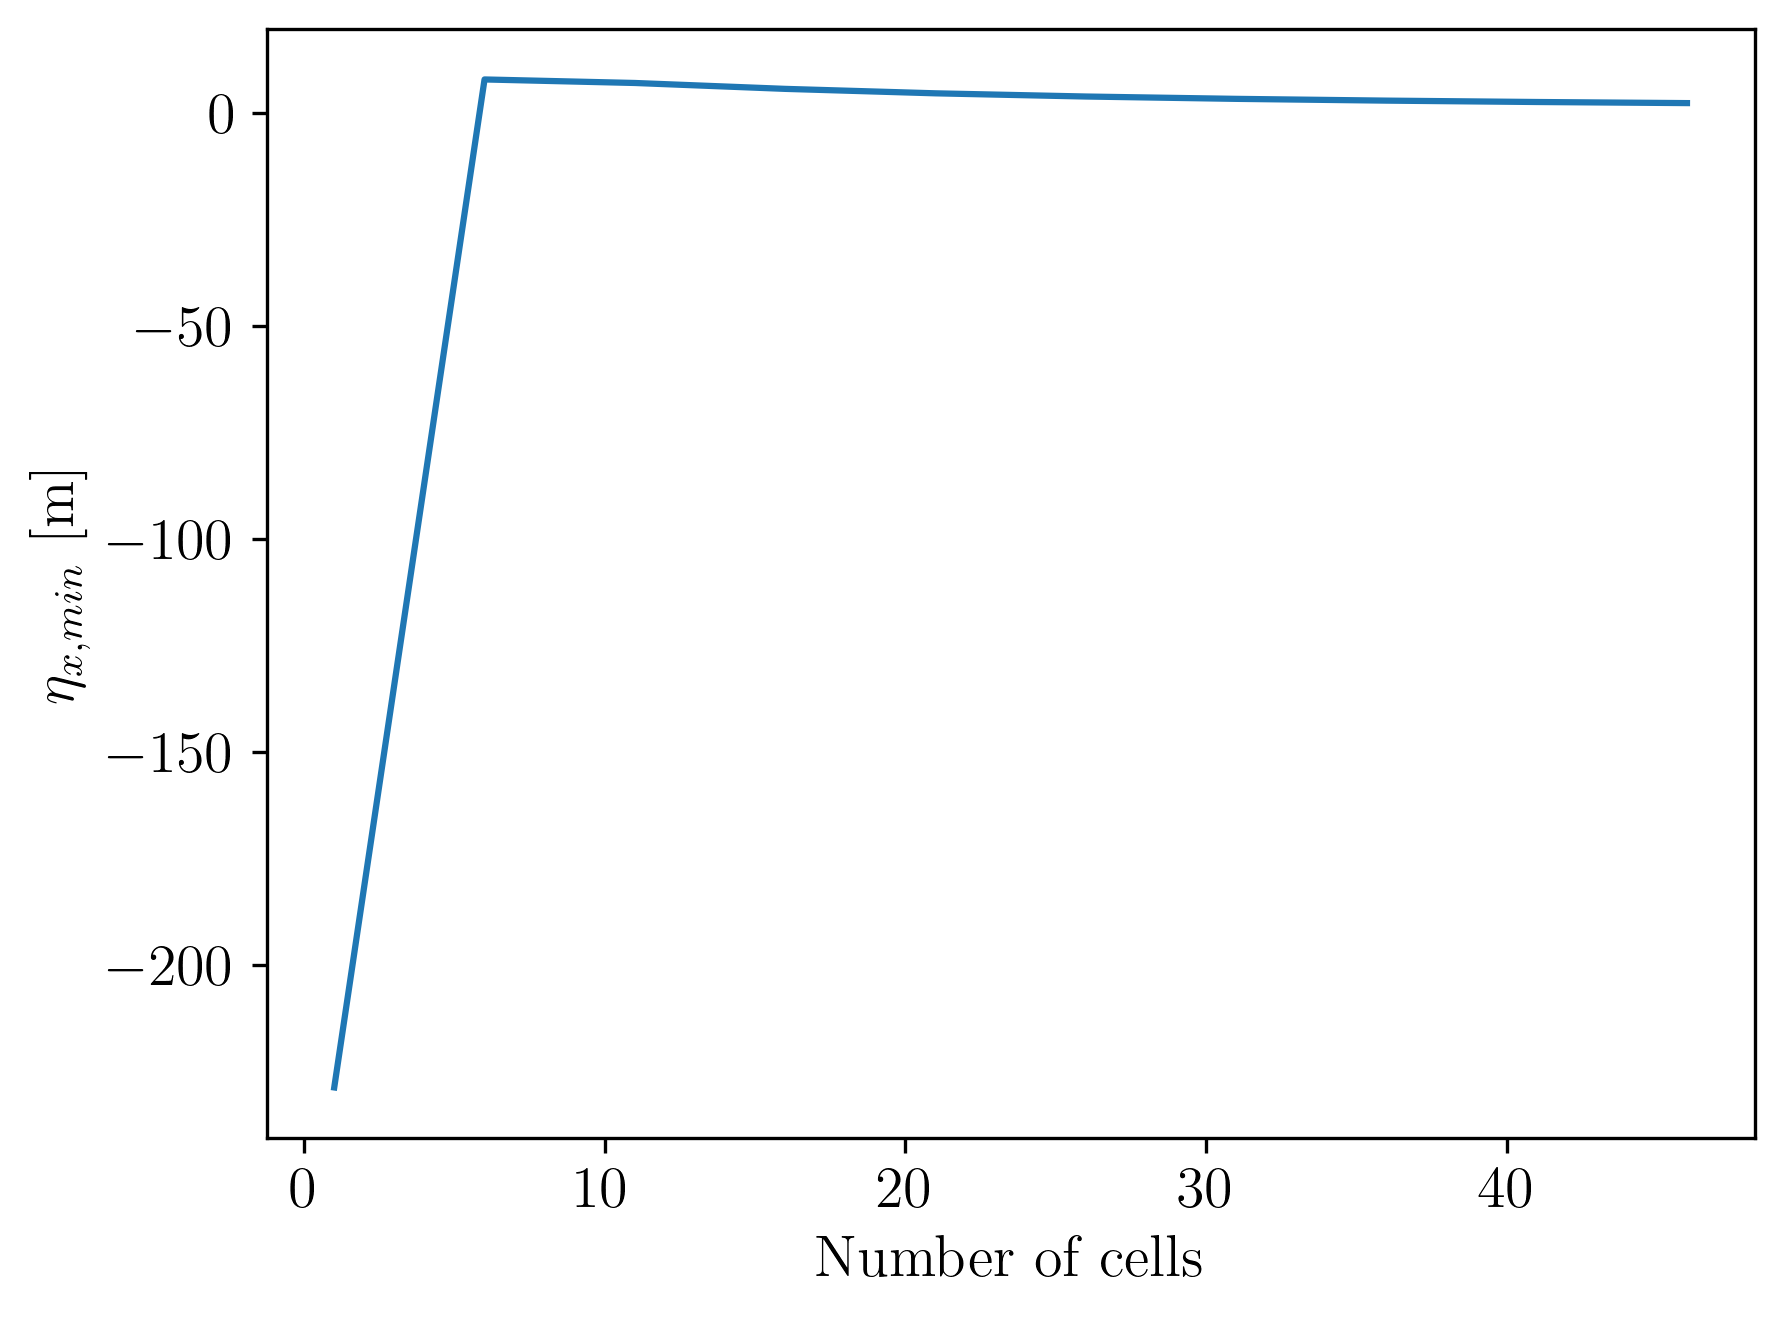

In [285]:
plt.plot(n_vals,dxmin_vals)
plt.ylabel('$\eta_{x,min}$ [m]')
plt.xlabel('Number of cells')
plt.show()

### Zero-chromaticity KSF and KSD

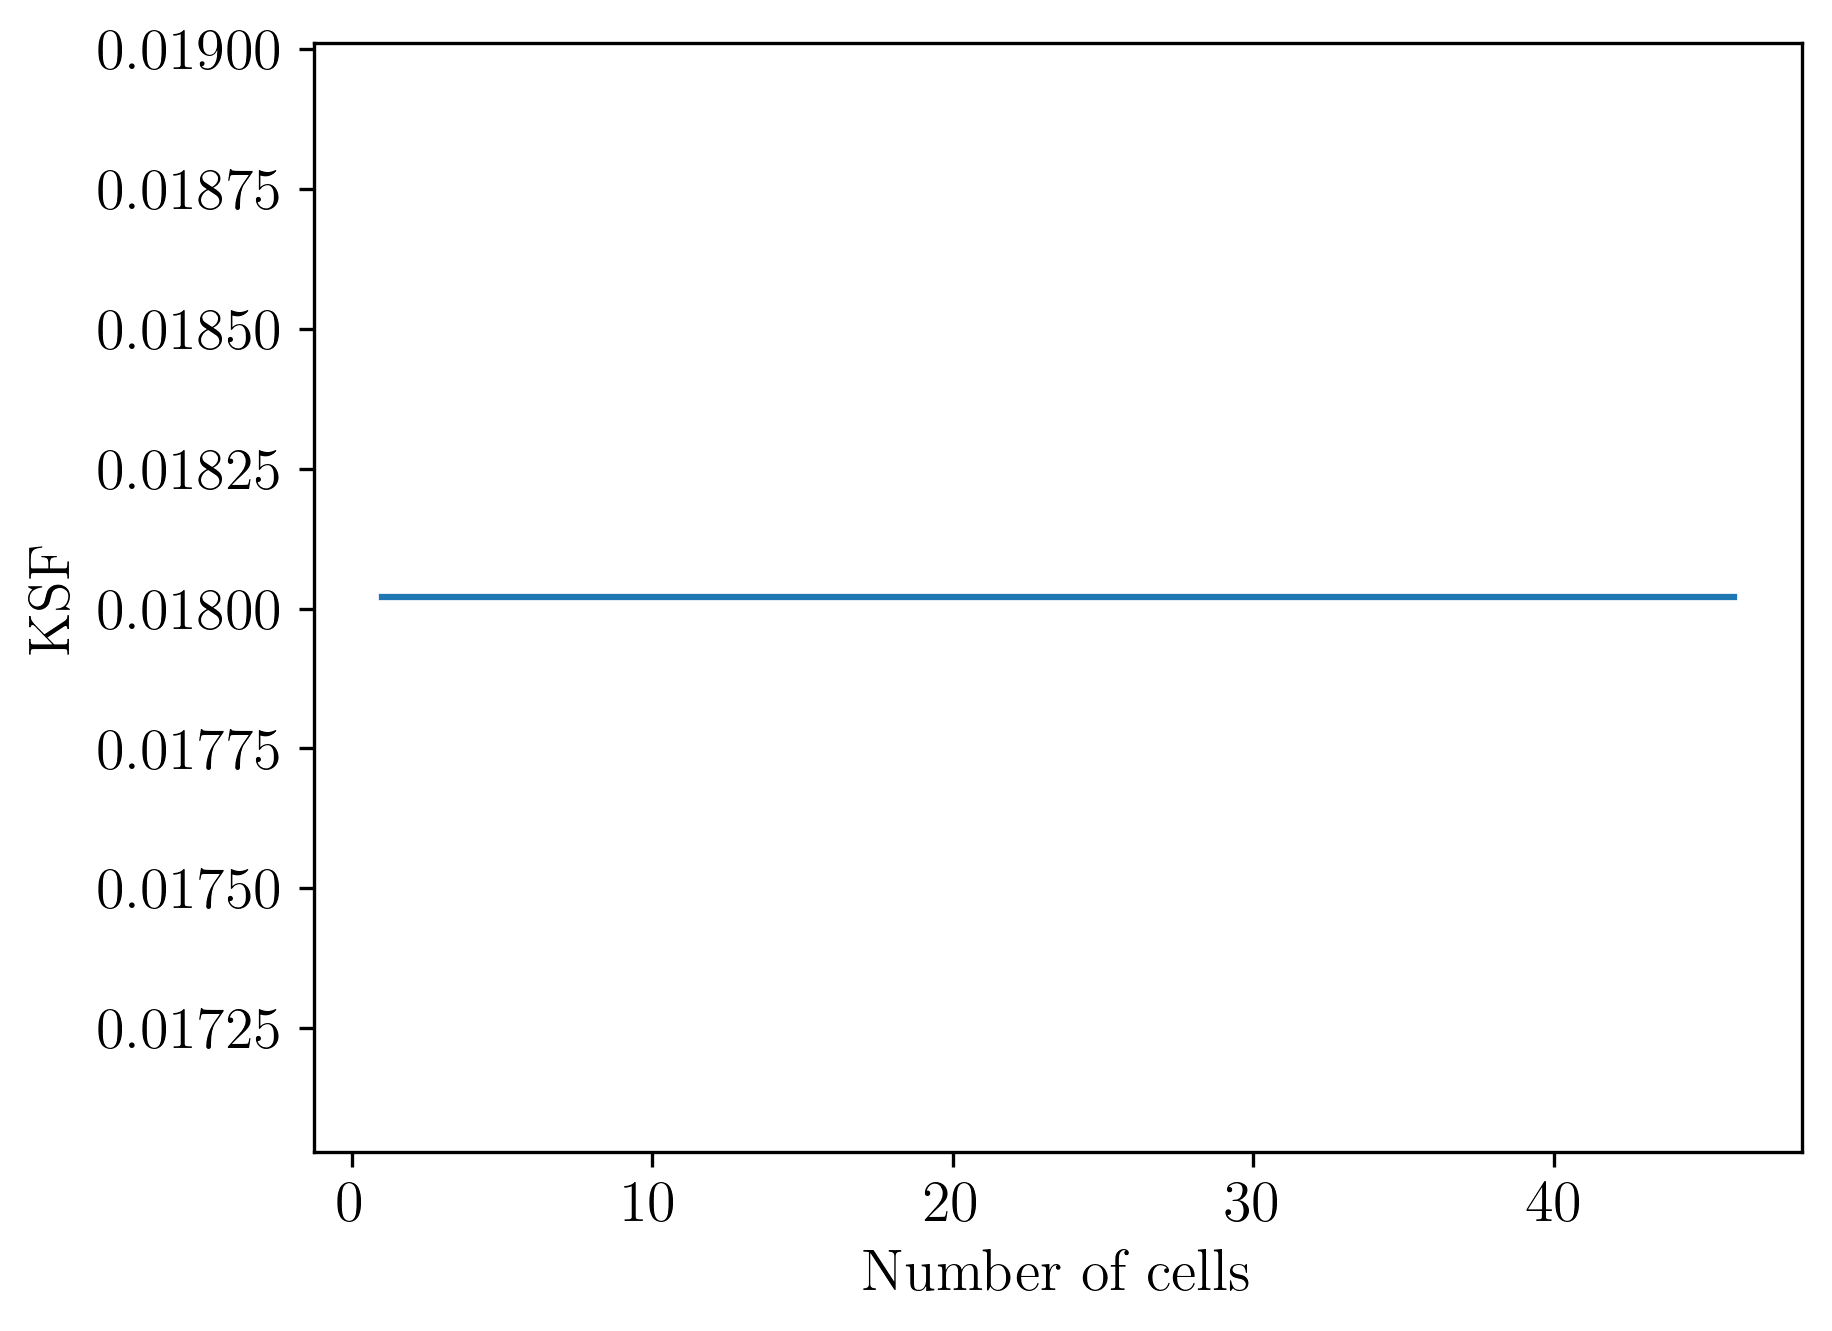

In [288]:
plt.plot(n_vals,ksf_vals)
plt.ylabel('KSF')
plt.xlabel('Number of cells')
plt.show()

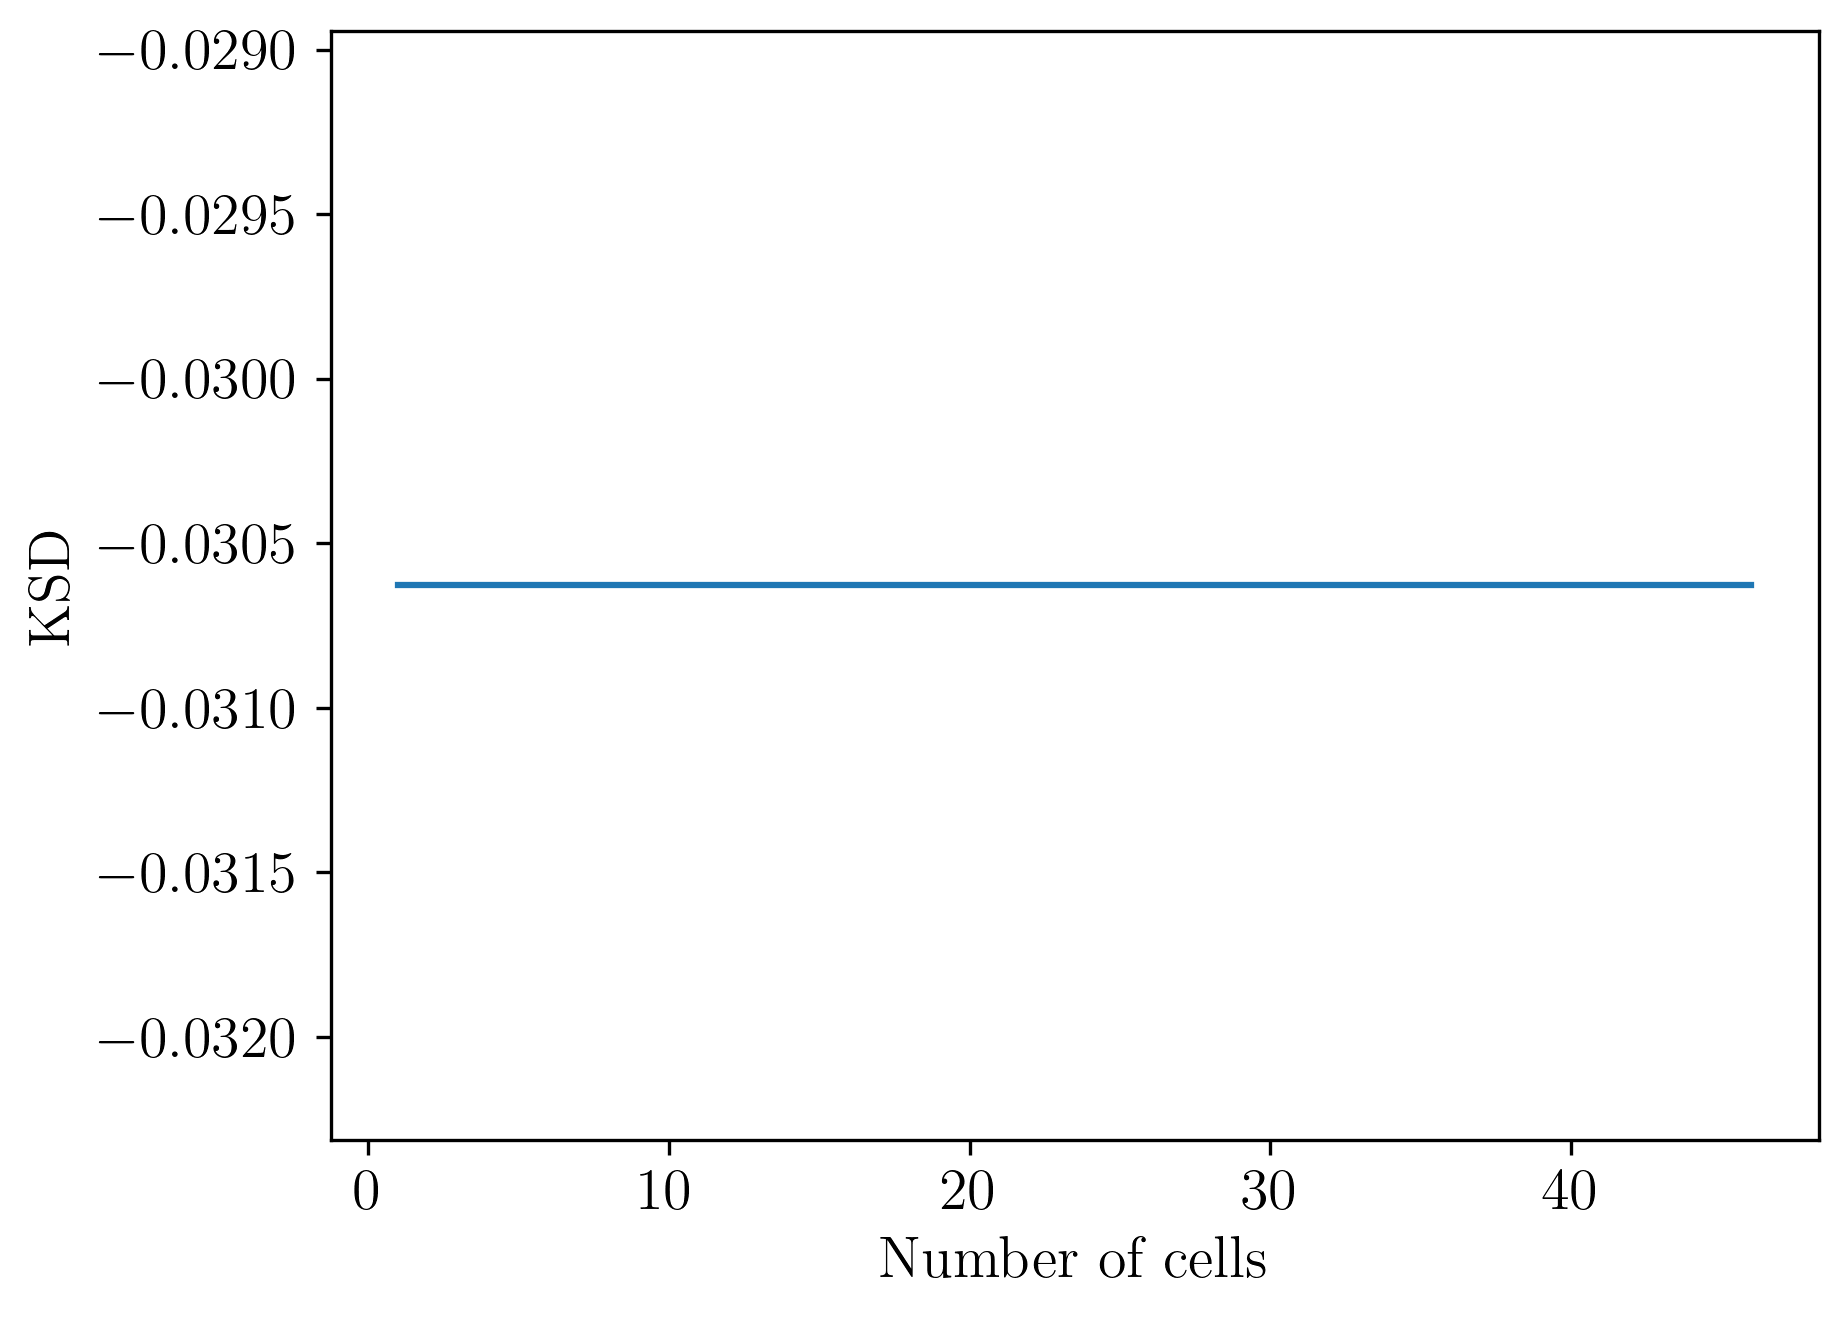

In [289]:
plt.plot(n_vals,ksd_vals)
plt.ylabel('KSD')
plt.xlabel('Number of cells')
plt.show()

### Observations

In [ ]:
############## write an interpretation of these results ##############